# Project Title

Netflix Data Analysis

An exploratory data analysis (EDA) project to understand trends, content distribution, and patterns in Netflix's catalog using python.

# Introduction

Netflix has grown into one of the leading streaming platforms worldwide. This project explores its content library to uncover patterns in content type. growth trends, genres and audience targeting.

The goal is to derive meaningful insights from the dataset and understand how Netflix;s content strategy has evolved over time.

# Objectives

- Analyze the distribution of Movies vs TV Shows
- Study content growth over time
- Identify the most common genres
- Explore country-wise content distribution
- Understood content ratings and audience targeting
- Analyze duration patterns for movies and TV shows

# Dataset Overview

The dataset contains information about Netflix titles, including:

- Title
- Type (Movies/TV Show)
- Director and Cast
- Country
- Release Year
- Rating
- Duration
- Genre

The dataset required cleaning due to missing values and inconsistent formats.

## Data Cleaning

The dataset contained several inconsistencies and missing values, which were handled as follows:

- Missing values in 'director', 'cast', and 'country' were replaced with appropriate labels  
- Incorrect and inconsistent values in the 'rating' column were standardized  
- Extra spaces in text fields were removed  
- Duplicate records were eliminated  
- The 'duration' column was processed to extract numerical values and units for better analysis  

These steps ensured the dataset was ready for analysis.

# Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
netflix = pd.read_csv("netflix_titles.csv")
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
netflix.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [7]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
netflix['director'] = netflix['director'].fillna('Unknown')
netflix['cast'] = netflix['cast'].fillna('Not Available')
netflix['country'] = netflix['country'].fillna('Unknown')

In [10]:
netflix['rating'] = netflix['rating'].fillna('Not Rated')

# Deleting Duplicates from the Dataset.

In [12]:
netflix = netflix.drop_duplicates()

In [13]:
netflix['duration_number'] = netflix['duration'].str.extract('(\d+)')
netflix['duration_number'] = netflix['duration_number'].astype(float)

In [14]:
netflix['duration_unit'] = netflix['duration'].str.extract('([a-zA-Z]+)')

In [15]:
movies = netflix[netflix['type'] == 'Movie']
tv_shows = netflix[netflix['type'] == 'TV Show']

In [11]:
netflix['title'] = netflix['title'].str.strip()
netflix['director'] = netflix['director'].str.strip()
netflix['cast'] = netflix['cast'].str.strip()
netflix['country'] = netflix['country'].str.strip()
netflix['rating'] = netflix['rating'].str.strip()
netflix['listed_in'] = netflix['listed_in'].str.strip()

# Viewing the Updated Dataset after deleting Duplicates.

In [17]:
netflix.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_number,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1.0,Season
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,min
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9.0,Seasons
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,min


# Splitting and counting individual genres

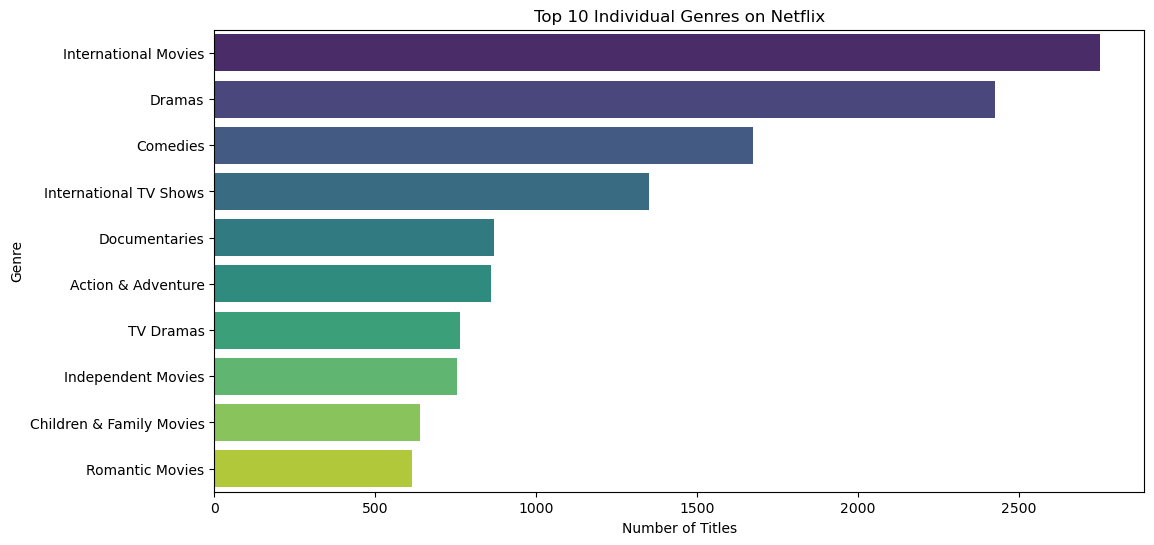

In [29]:
genres = netflix['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values, 
    y=top_genres.index, 
    hue=top_genres.index, 
    palette='viridis', 
    legend=False
)

plt.title("Top 10 Individual Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

# Sort the order so seasons appear as 1, 2, 3... instead of random order

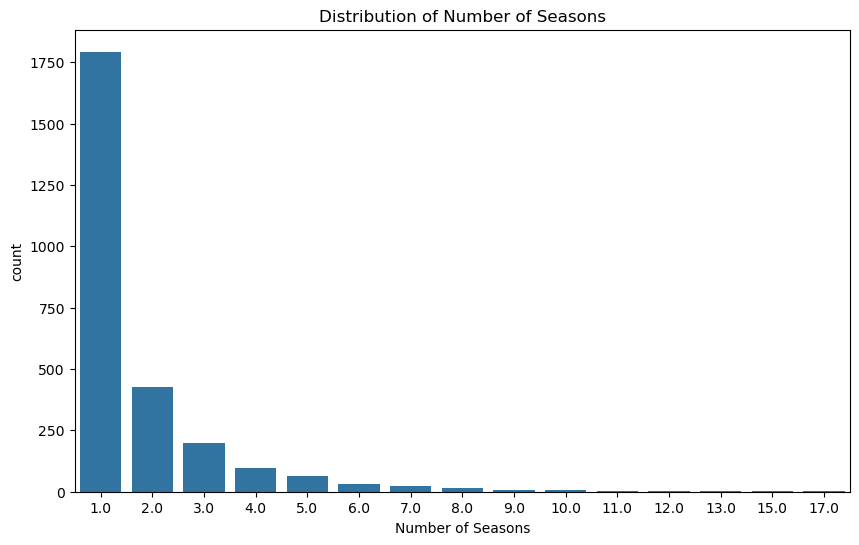

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(data=tv_shows, x='duration_number', order=tv_shows['duration_number'].value_counts().index.sort_values())

plt.title("Distribution of Number of Seasons")
plt.xlabel("Number of Seasons")
plt.show()

# 1. Movies vs TV Shows

This analysis explores the distribution of content types available on Netflix.

## Insights: ##
Movies dominate the Netflix library, making up the majority of available content. However, TV Shows still represent a signficant portion, indicating a balanced but movie-heavy catalog.

In [ ]:
# Understanding the distribution of content types on Netflix

content_type_counts = netflix['type'].value_counts()

plt.figure()
content_type_counts.plot(kind='bar')

plt.title("Distribution of Movies Vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

# 2. Content Growth Over Time

This section analyzes how Netflix’s content library has expanded over the years.

**Insight:**  
Content production saw a sharp rise starting around 2015, reflecting Netflix’s global expansion and increased investment in original content.

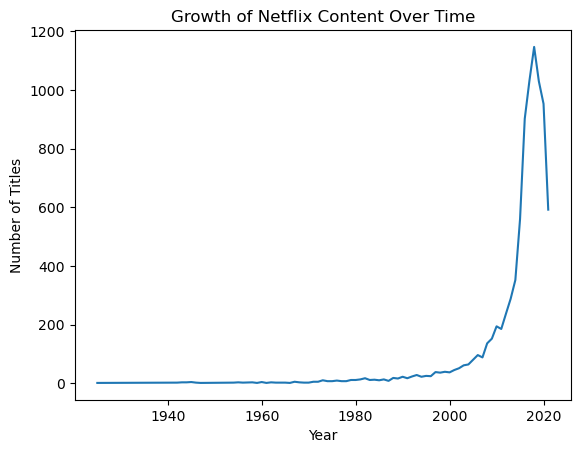

In [19]:
# Analyzing how Netflix content has grown over the years

content_by_year = netflix['release_year'].value_counts().sort_index()

plt.figure()
content_by_year.plot(kind='line')

plt.title("Growth of Netflix Content Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

# 3. Genre Analysis

This analysis identifies the most common genres available on Netflix.

**Insight:**  
Drama and Comedy are the most dominant genres, suggesting a focus on widely appealing content across global audiences.

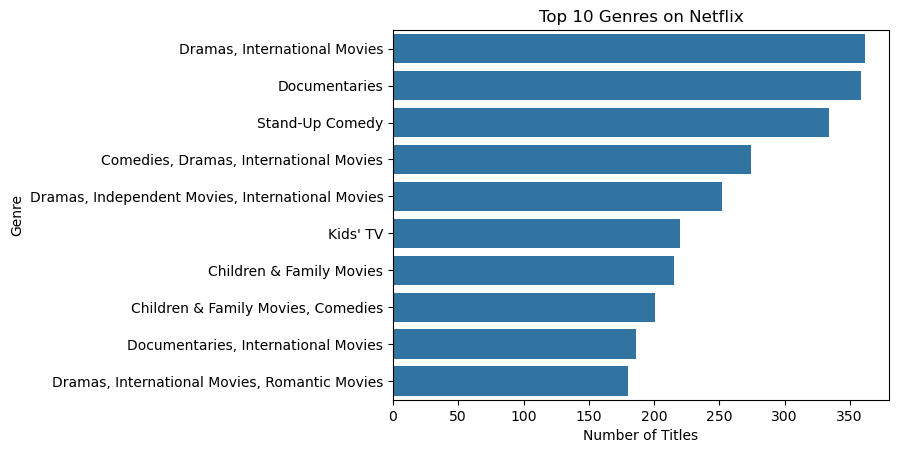

In [20]:
# Identifying the most common genres on Netflix

top_genres = netflix['listed_in'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

# 4. Country-wise Content Distribution

This section examines which countries contribute the most content.

**Insight:**  
The United States leads in content production, followed by countries like India and the UK, highlighting Netflix’s strong global presence.

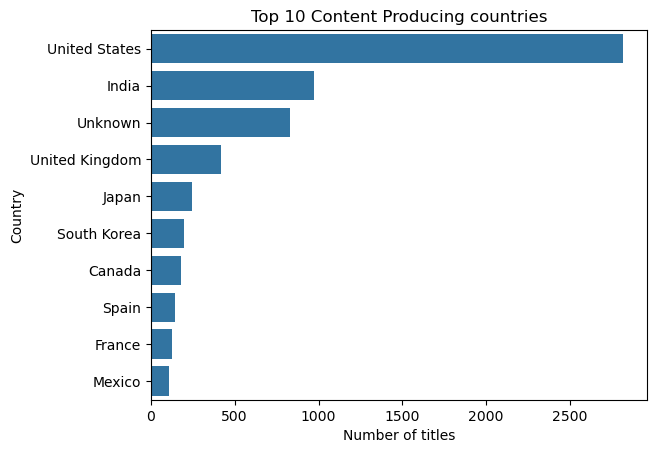

In [21]:
# Finding Which countries contribute the most content

top_countries = netflix['country'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Content Producing countries")
plt.xlabel("Number of titles")
plt.ylabel("Country")

plt.show()

# 5. Content Rating Distribution

This analysis explores the types of audience Netflix content is targeted toward.

**Insight:**  
Most content is rated TV-MA and TV-14, indicating a focus on mature and teenage audiences.

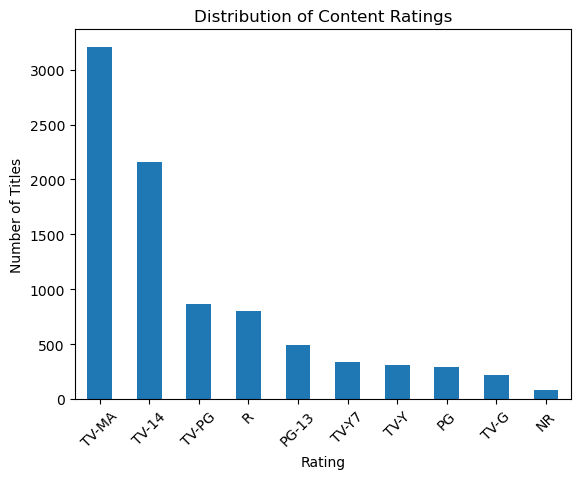

In [22]:
# Understanding the distribution of content ratings

rating_counts = netflix['rating'].value_counts().head(10)

plt.figure()
rating_counts.plot(kind='bar')

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

# 6. Movie Duration Analysis

This section analyzes the distribution of movie lengths.

**Insight:**  
Most movies fall within the 80–120 minute range, aligning with standard feature-length films.

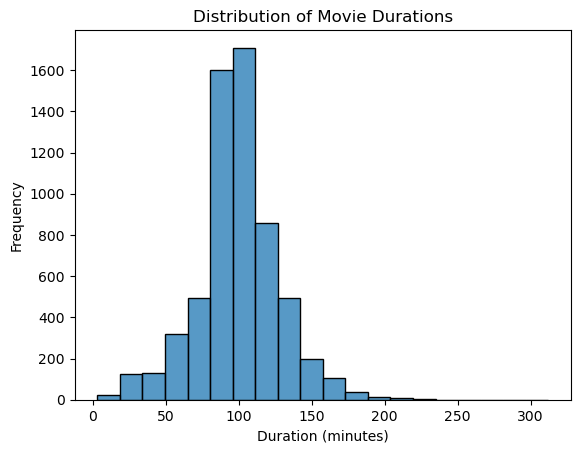

In [23]:
# Analyzing the duration of movies on Netflix

movies = netflix[netflix['type'] == 'Movie']

plt.figure()
sns.histplot(movies['duration_number'], bins=20)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.show()

# 7. TV Show Seasons Analysis

This analysis examines how many seasons TV shows typically have.

**Insight:**  
Most TV shows have 1–2 seasons, suggesting a preference for shorter series formats.

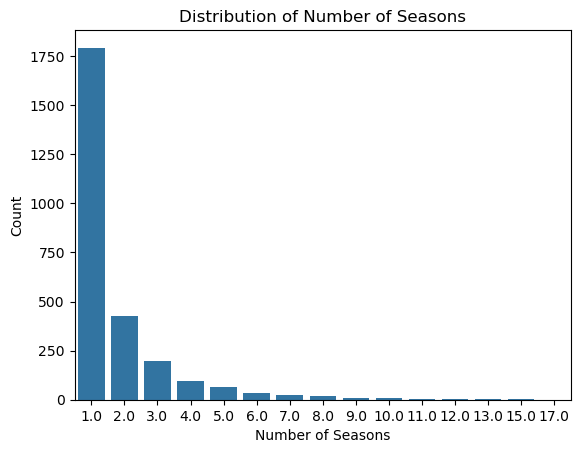

In [24]:
# Analyzing how many seasons TV shows typically have

tv_shows = netflix[netflix['type'] == 'TV Show']

plt.figure()
sns.countplot(x=tv_shows['duration_number'])

plt.title("Distribution of Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")

plt.show()

# 8. Movies vs TV Shows Over Time

This section compares how Movies and TV Shows have evolved over time.

**Insight:**  
While movies remain dominant, TV Shows have increased significantly in recent years, indicating a shift toward episodic content.

<Figure size 640x480 with 0 Axes>

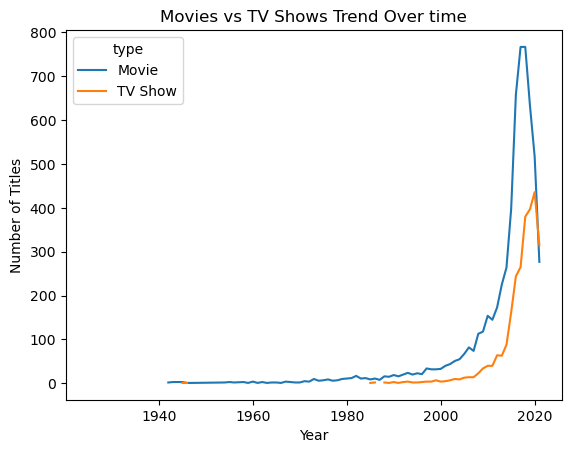

In [25]:
# Comparing how Movies and TV Shows have evolved over time

content_trend = netflix.groupby(['release_year', 'type']).size().unstack()

plt.figure()
content_trend.plot()

plt.title("Movies vs TV Shows Trend Over time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

## Conclusion

The analysis reveals that Netflix has a strong focus on movies, although TV shows have been growing rapidly in recent years. The platform emphasizes widely appealing genres such as Drama and Comedy, while also expanding its global content library.

The dominance of mature content ratings suggests that Netflix primarily targets adult and teenage audiences. Additionally, most movies follow standard durations, and TV shows tend to have shorter runs.

Overall, Netflix’s content strategy reflects a balance between global expansion and audience-driven content creation.